In [1]:
/content/drive/MyDrive/Colab Notebooks/WEEK02/breast_cancer.csv

NameError: name 'content' is not defined

In [2]:
# breast_cancer.csv 파일을 바탕으로 LR, DT, RF Regression 실습
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/WEEK02/breast_cancer.csv'

df2 = pd.read_csv(path)
df2.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df = df2.drop('label', axis=1)
df.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# worst compactness 기준으로 예측
y = df2['worst compactness']
y.value_counts()
y

,worst compactness
0,0.66560
1,0.18660
2,0.42450
3,0.86630
4,0.20500
...,...
564,0.21130
565,0.19220
566,0.30940
567,0.86810


In [ ]:
X = df2.drop('worst compactness', axis=1)
X.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.metrics import mean_squared_error

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error


--- Linear Regression ---
평균제곱오차(MSE) : 0.0004940829358206368
평균제곱오차(MSE) numpy : 0.0004940829358206368
평균제곱오차(MSE) 직접구현 : 0.0004940829358206369


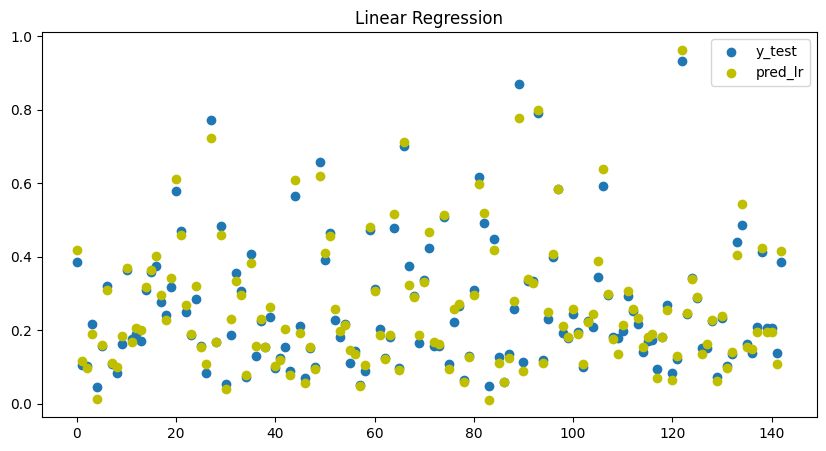

In [ ]:
# LR
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print('\n--- Linear Regression ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_lr))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_lr))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_lr))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_lr)), pred_lr, c='y', label='pred_lr')
plt.title('Linear Regression')
plt.legend()
plt.show()


--- Decision Tree Regressor ---
평균제곱오차(MSE) : 0.0076953601748251735
평균제곱오차(MSE) numpy : 0.0076953601748251735
평균제곱오차(MSE) 직접구현 : 0.007695360174825181


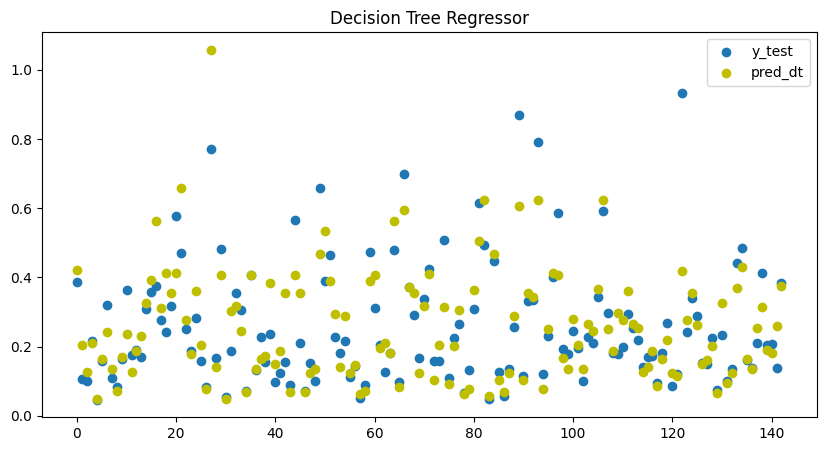

In [ ]:
# DT
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=0)
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)

print('\n--- Decision Tree Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_dt))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_dt))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_dt))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_dt)), pred_dt, c='y', label='pred_dt')
plt.title('Decision Tree Regressor')
plt.legend()
plt.show()


--- Random Forest Regressor ---
평균제곱오차(MSE) : 0.00219169173441545
평균제곱오차(MSE) numpy : 0.00219169173441545
평균제곱오차(MSE) 직접구현 : 0.002191691734415451


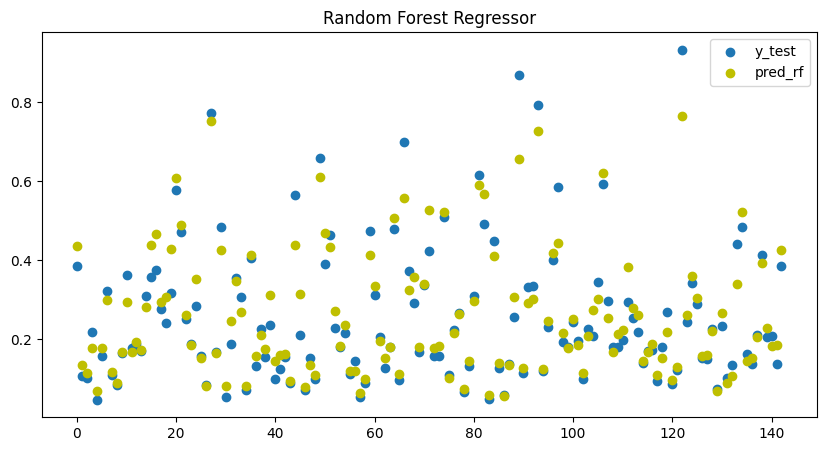

In [ ]:
# RF
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=0)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print('\n--- Random Forest Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_rf))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_rf))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_rf))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_rf)), pred_rf, c='y', label='pred_rf')
plt.title('Random Forest Regressor')
plt.legend()
plt.show()